# **2. What is driving the business decline?**

In the previous section, **Product Health Overview**, the product showed growing user demand but declining Conversion-to-Paid subscription. **This section investigates where the decline comes from.**

**Assumptions**:

January 2024 to November 2025 will be used for analysis as:
- 2022-2023 volume is too small
- December 2025 users do not have enough time to convert as December'25 is the last month and for the conversions it is important to have the equal windows for all users


##**2.0 Data, libraries and functions import**

In [ ]:
# -----------------
# loading libraries
# -----------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
# -----------------
# loading functions
# -----------------

from preprocessing import bulk_convert_to_datetime

from visualizing import line_chart_formatting

from conversions import (
    bulk_maturity_flags,
    cr_calculation
)

In [ ]:
# ---------------
# loading sources
# ---------------

users = pd.read_csv('users_adjusted.csv')
trials = pd.read_csv('trials_adjusted.csv')
subscriptions = pd.read_csv('subscriptions_adjusted.csv')
payments = pd.read_csv('payments_adjusted.csv')

## **2.1. Processing columns**
### **2.1.0. Column conversion to work with them further**

In [ ]:
# ------------------------------------------------------------------------------
# applying pd.to_datetime to date columns
# ------------------------------------------------------------------------------
columns = [(users, 'registration_date'),
           (users, 'registration_month'),
           (users, 'registration_week'),

           (trials, 'trial_start_date'),
           (trials, 'trial_end_date'),
           (trials, 'trial_start_month'),

           (payments, 'payment_start_date'),
           (payments, 'payment_month'),
           (payments, 'billing_period_start'),
           (payments, 'billing_period_end'),

           (subscriptions, 'subscription_start_date'),
           (subscriptions, 'subscription_end_date'),
           (subscriptions, 'subscription_month'),
           (subscriptions, 'subscription_end_month'),

           (subscriptions, 'plan_change_date'),
           (subscriptions, 'cancellation_date'),
           (subscriptions, 'cancellation_month')]

bulk_convert_to_datetime (columns)

## **2.2. Funnel breakdown**

To identify where paid conversion starts to decline, I split the funnel into:

* **Registration > Trial**
* **Trial > Paid**
* **Registration > Paid**

The previous section showed that trial volume is not declining, so registration-to-trial is not expected to be the main issue and will be checked as a validation step. The main focus is on trial-to-paid conversion.

**Metric logic**: To make cohorts comparable and avoid giving older cohorts more time to convert than newer cohorts I use a **30-day window**. It gives users enough time to complete the 14 days trial and start a subscription.



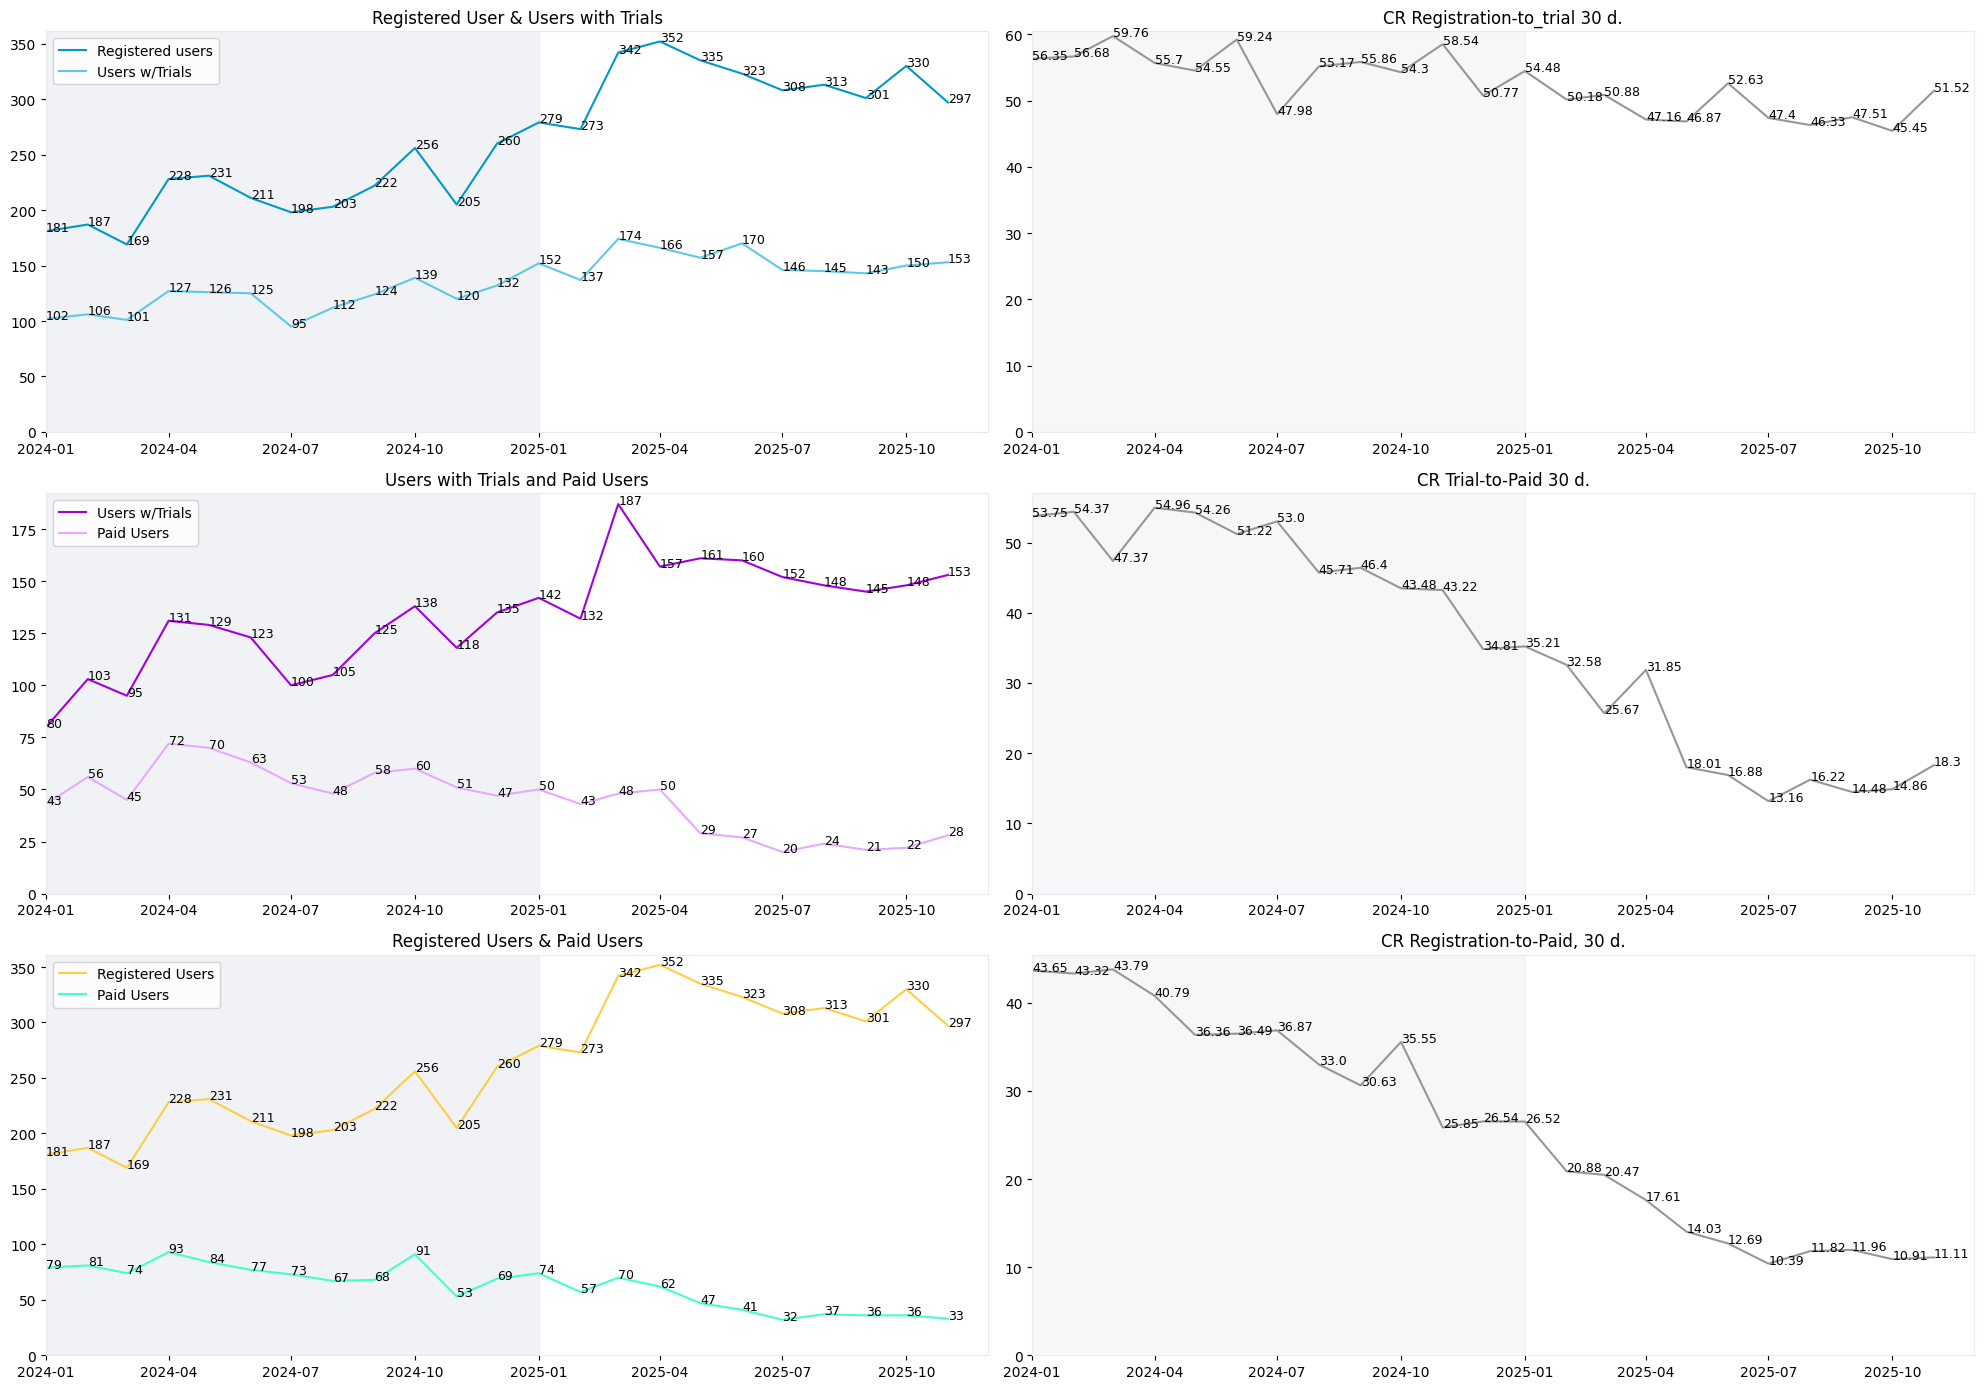

In [ ]:
registration_to_trial = users.merge(trials, on = 'user_id', how = 'left')

first_subscription_by_user = (subscriptions.groupby('user_id', as_index = False)
                                                    ['subscription_start_date'].min()
                                                   .rename(columns = {'subscription_start_date' : 'subscription_first_date'}))

registration_to_trial = registration_to_trial.merge(first_subscription_by_user, on = 'user_id', how = 'left')

registration_to_trial['trial_no_trial'] = np.where(~registration_to_trial['trial_id'].isna(), True, False)

registration_to_trial['age_groups'] = pd.cut(registration_to_trial['age'],
                                             bins = [17, 24, 34, 44, 100],
                                             labels = ['18-24', '25-34', '35-44', '45+'])

tables = [
          (registration_to_trial, 'registration_date', 'trial_start_date', 30),

          (registration_to_trial, 'trial_start_date', 'subscription_first_date', 30),

          (registration_to_trial, 'registration_date', 'subscription_first_date', 30)
          ]

bulk_maturity_flags(tables)

# periods in the analysis
period_min = '2024-01-01'
period_max = '2025-11-30'

registration_to_trial = registration_to_trial[(registration_to_trial['registration_date'] >= period_min)
                                              &(registration_to_trial['registration_date'] <= period_max)].copy()

CR_table = cr_calculation (registration_to_trial,
                              ['registration_month'],
                              'flag_window_30_days_reg_to_tri_maturity',
                              'flag_window_30_days_reg_to_tri_conversion',
                              'CR_reg_to_tri',
                              rounded_number = 2)

CR_table =  CR_table.merge(cr_calculation (registration_to_trial,
                                            ['trial_start_month'],
                                            'flag_window_30_days_tri_to_sub_maturity',
                                            'flag_window_30_days_tri_to_sub_conversion',
                                            'CR_tri_to_sub',
                                            rounded_number = 2),
                            left_on = 'registration_month',
                            right_on = 'trial_start_month',
                            how = 'left')

CR_table =  CR_table.merge(cr_calculation (registration_to_trial,
                                            ['registration_month'],
                                            'flag_window_30_days_reg_to_sub_maturity',
                                            'flag_window_30_days_reg_to_sub_conversion',
                                            'CR_reg_to_sub',
                                            rounded_number = 2),
                            on = 'registration_month',
                            how = 'left')

fig, ax = plt.subplots(3, 2, figsize = (20,14))

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_tri_maturity',
                        chart_type = 'line',
                        title = 'Registered User & Users with Trials',
                        main_color = '#0098C7',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Registered users',
                        min_y = 0,
                        ax = ax[0,0]
                        )

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_tri_conversion',
                        chart_type = 'line',
                        title = 'Registered User & Users with Trials',
                        main_color = '#5EC8E8',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Users w/Trials',
                        min_y = 0,
                        ax = ax[0,0]
                        )
ax[0, 0].legend(loc = 'upper left')

line_chart_formatting (CR_table,
                        'registration_month',
                        'CR_reg_to_tri',
                        chart_type = 'line',
                        title = 'CR Registration-to_trial 30 d.',
                        main_color = '#969696',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = None,
                        min_y = 0,
                        ax = ax[0,1]
                        )

line_chart_formatting (CR_table,
                        'trial_start_month',
                        'flag_window_30_days_tri_to_sub_maturity',
                        chart_type = 'line',
                        title = 'Users with Trials and Paid Users',
                        main_color = '#A100DB',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Users w/Trials',
                        min_y = 0,
                        ax = ax[1,0]
                        )

line_chart_formatting (CR_table,
                        'trial_start_month',
                        'flag_window_30_days_tri_to_sub_conversion',
                        chart_type = 'line',
                        title = 'Users with Trials and Paid Users',
                        main_color = '#E8A8FF',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Paid Users',
                        min_y = 0,
                        ax = ax[1,0]
                        )
ax[1, 0].legend(loc = 'upper left')

line_chart_formatting (CR_table,
                        'trial_start_month',
                        'CR_tri_to_sub',
                        chart_type = 'line',
                        title = 'CR Trial-to-Paid 30 d.',
                        main_color = '#969696',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = None,
                        min_y = 0,
                        ax = ax[1,1]
                        )

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_sub_maturity',
                        chart_type = 'line',
                        title = 'Registered Users & Paid Users',
                        main_color = '#FFCD42',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Registered Users',
                        min_y = 0,
                        ax = ax[2,0]
                        )

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_sub_conversion',
                        chart_type = 'line',
                        title = 'Registered Users & Paid Users',
                        main_color = '#42FFCD',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Paid Users',
                        min_y = 0,
                        ax = ax[2,0]
                        )
ax[2, 0].legend(loc = 'upper left')

line_chart_formatting (CR_table,
                        'registration_month',
                        'CR_reg_to_sub',
                        chart_type = 'line',
                        title = 'CR Registration-to-Paid, 30 d.',
                        main_color = '#969696',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = '',
                        min_y = 0,
                        ax = ax[2,1]
                        )
plt.tight_layout()
plt.show()

#### **Intermediate result**

Registration-to-trial conversion is relatively stable.

The main decline happens later in the funnel: **Trial-to-Paid subscribers**.

## **2.3. Trial vs no-trial users**

Not all users start with a trial, so I also check users who convert directly from registration to paid subscription **without trial**.

This step is important because if only trial users decline, the issue is likely connected to the trial-to-paid experience. If no-trial users also decline, the problem may be broader and related to pricing, checkout, payment, or certain frictions within the app.

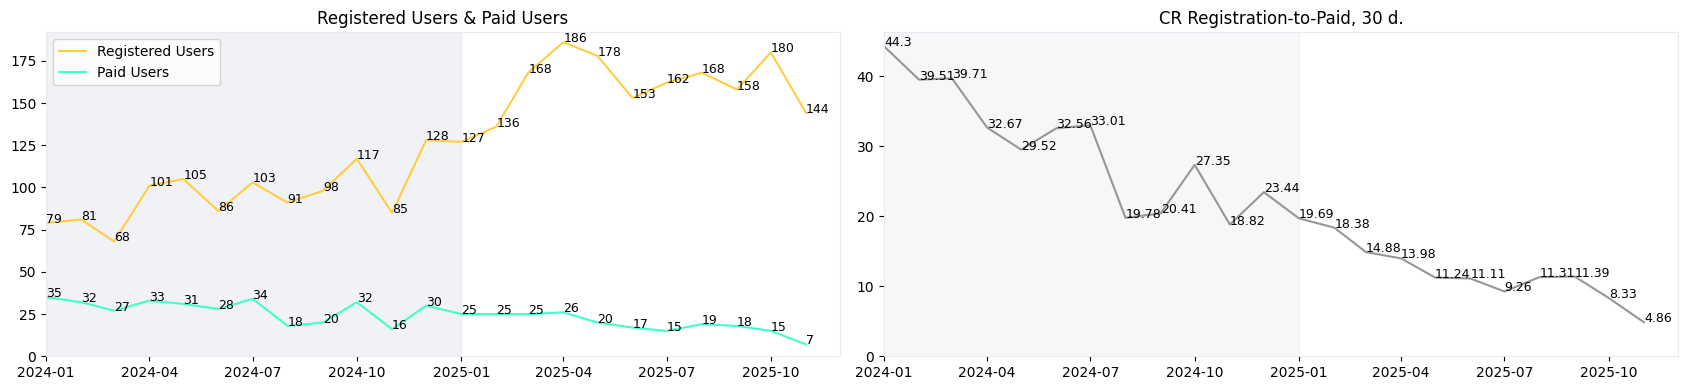

In [ ]:
CR_no_trial = registration_to_trial[registration_to_trial['trial_no_trial'] == False].rename(columns = {'flag_window_30_days_reg_to_sub_maturity' : 'flag_window_30_days_reg_to_sub_maturity_nt',
                                                                                                        'flag_window_30_days_reg_to_sub_conversion' : 'flag_window_30_days_reg_to_sub_conversion_nt'})

CR_table =  CR_table.merge(cr_calculation (CR_no_trial,
                                            ['registration_month'],
                                            'flag_window_30_days_reg_to_sub_maturity_nt',
                                            'flag_window_30_days_reg_to_sub_conversion_nt',
                                            'CR_reg_to_sub_nt',
                                            rounded_number = 2),
                            on = 'registration_month',
                            how = 'left')

fig, ax = plt.subplots(1, 2, figsize = (17,4))

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_sub_maturity_nt',
                        chart_type = 'line',
                        title = 'Registered Users & Paid Users',
                        main_color = '#FFCD42',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Registered Users',
                        min_y = 0,
                        ax = ax[0]
                        )

line_chart_formatting (CR_table,
                        'registration_month',
                        'flag_window_30_days_reg_to_sub_conversion_nt',
                        chart_type = 'line',
                        title = 'Registered Users & Paid Users',
                        main_color = '#42FFCD',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Paid Users',
                        min_y = 0,
                        ax = ax[0]
                        )
ax[0].legend(loc = 'upper left')

line_chart_formatting (CR_table,
                        'registration_month',
                        'CR_reg_to_sub_nt',
                        chart_type = 'line',
                        title = 'CR Registration-to-Paid, 30 d.',
                        main_color = '#969696',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = None,
                        min_y = 0,
                        ax = ax[1]
                        )
plt.tight_layout()
plt.show()

#### **Intermediate result**

No-trial registration-to-paid conversion also declines.

The next step is to identify which user segments contribute most to this change.

## **2.4. CR trends by Segment**

Next, I compare conversion across devices, acquisition sources, regions, age groups.

First, it is necessary to review the volumes to identify the largest segments and avoid overinterpreting small ones and only after then to compare conversion rates.


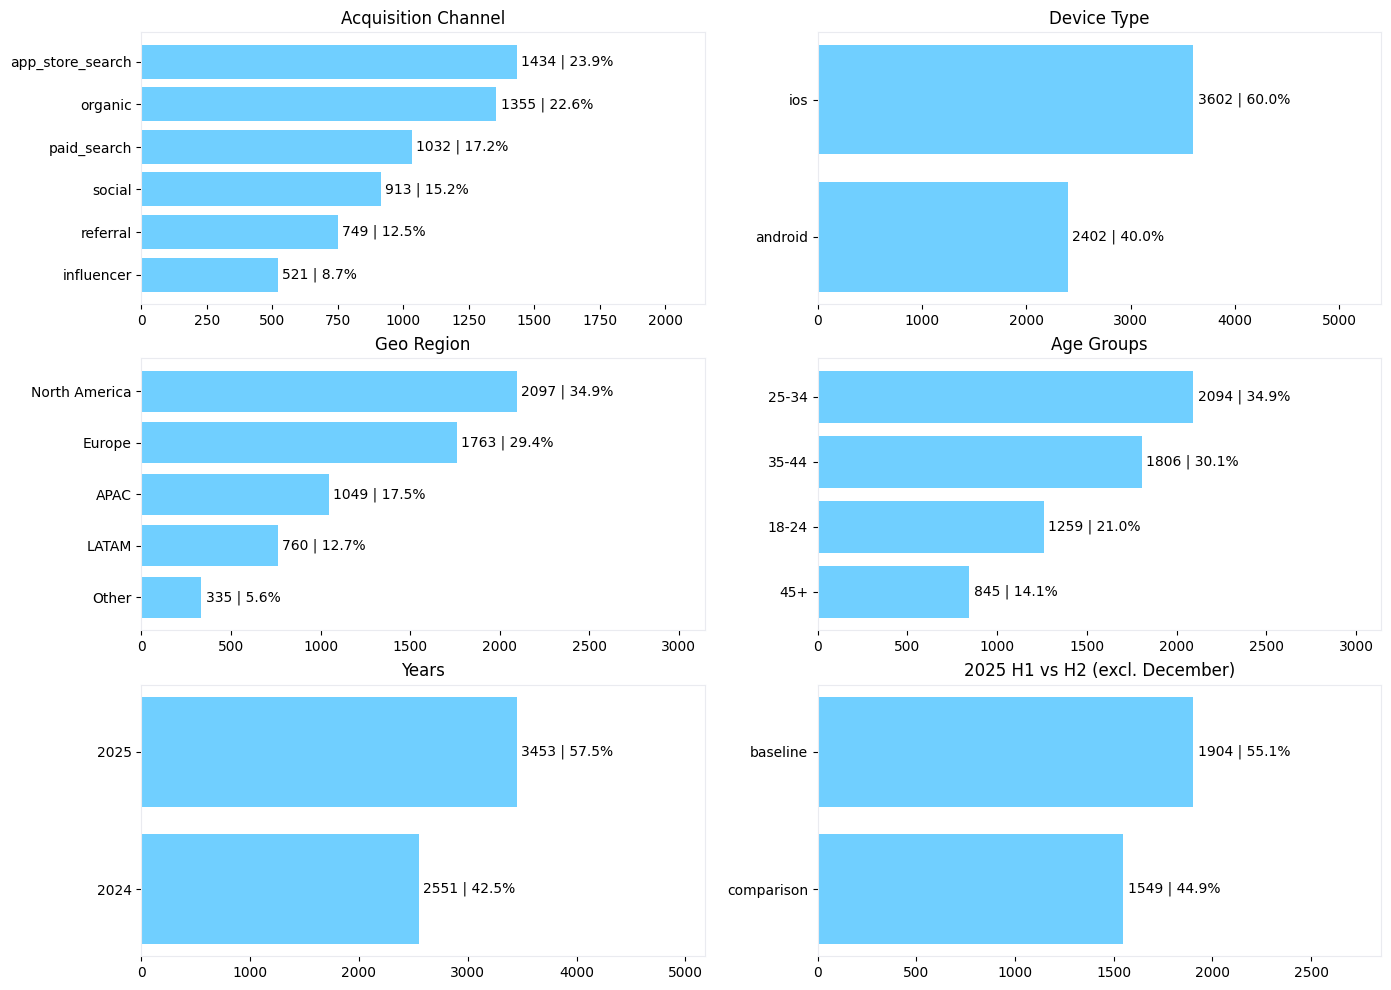

In [ ]:
def group_and_total (table, column_for_groups, column_for_nunique):

  new_table  = (table.groupby(column_for_groups, as_index = False, observed = False)
                                                      [column_for_nunique].nunique().sort_values(by = column_for_nunique, ascending = True))
  new_table['share'] = round(new_table[column_for_nunique] / new_table[column_for_nunique].sum()*100, 1)

  return new_table


# adding period slices to assess the volume
registration_to_trial['years'] = registration_to_trial['registration_date'].dt.year.astype('string')

registration_to_trial['2025_period_for_comparison'] = np.select([registration_to_trial['registration_date'].between('2025-01-01', '2025-06-30'),
                                                              registration_to_trial['registration_date'].between('2025-07-01', '2025-11-30')],
                                                              ['baseline',
                                                               'comparison'],
                                                              default = 'not relevant')

# preparing the data for the barcharts
grouped_acquisition_channel = group_and_total(registration_to_trial, 'acquisition_channel', 'user_id')
grouped_geo_region = group_and_total(registration_to_trial, 'geo_region', 'user_id')
grouped_device_type = group_and_total(registration_to_trial, 'device_type', 'user_id')
grouped_age_groups = group_and_total(registration_to_trial, 'age_groups', 'user_id')
grouped_years = group_and_total(registration_to_trial, 'years', 'user_id')
grouped_2025_periods = group_and_total(registration_to_trial[registration_to_trial['2025_period_for_comparison'] != 'not relevant'], '2025_period_for_comparison', 'user_id')


fig, ax = plt.subplots(3, 2, figsize=(16, 12))

plots = [
    (ax[0, 0], grouped_acquisition_channel, 'acquisition_channel', 'Acquisition Channel'),
    (ax[0, 1], grouped_device_type, 'device_type', 'Device Type'),
    (ax[1, 0], grouped_geo_region, 'geo_region', 'Geo Region'),
    (ax[1, 1], grouped_age_groups, 'age_groups', 'Age Groups'),
    (ax[2, 0], grouped_years, 'years', 'Years'),
    (ax[2, 1], grouped_2025_periods, '2025_period_for_comparison', '2025 H1 vs H2 (excl. December)')
]

for axis, df, category_col, title in plots:
    bars = axis.barh(df[category_col], df['user_id'], color = '#70CFFF')
    axis.bar_label(bars, labels = df['user_id'].astype('str') +' | '+ df['share'].astype('str') + '%', padding=3)
    axis.set_title(title)
    axis.set_xlim(0, df['user_id'].max() * 1.5)

    axis.spines['top'].set_color('#EAEBF0')
    axis.spines['bottom'].set_color('#EAEBF0')
    axis.spines['left'].set_color('#EAEBF0')
    axis.spines['right'].set_color('#EAEBF0')

plt.show()



Some segments have few users, so monthly conversion rates can change sharply because of the small volumes. To make the comparison more reliable, I compare 2024 vs 2025 instead of monthly comparison.

## **2.5. Segment indicator table**

The indicator table compares 30-day registration-to-paid conversion rates by segment between:

* **Baseline:** January – December 2024
* **Comparison:** January – November 2025

For each segment, the table shows:

* mature users in both periods;
* converted users in both periods;
* baseline and comparison conversion rates;
* the change in percentage points.

This format reduces noise from small monthly samples while showing where the decline is concentrated.

In [ ]:
indicator_table_prep = registration_to_trial[registration_to_trial['years'] != 'not relevant'].copy()

indicator_table_prep['subgroup'] = 'Total'

list_for_groupping = ['subgroup', 'acquisition_channel', 'geo_region', 'device_type', 'age_groups']

n = 0
final_table = []

while n < len(list_for_groupping):

  helper_table = (indicator_table_prep.groupby(['years', list_for_groupping[n]], as_index = False, observed = True)
                                          .agg(denominator = ('flag_window_30_days_reg_to_sub_maturity', 'sum'),
                                              numerator = ('flag_window_30_days_reg_to_sub_conversion', 'sum')))
  helper_table['CR'] = (helper_table['numerator'] / helper_table['denominator'] * 100)
  helper_table.rename(columns = {list_for_groupping[n] : 'subgroup'}, inplace = True)
  helper_table['group'] = list_for_groupping[n]
  final_table.append(helper_table)

  n += 1

final_table = pd.concat(final_table, ignore_index=True)

final_table = final_table.pivot(
                                      index = ['group', 'subgroup'],
                                      columns = 'years',
                                      values = ['denominator', 'numerator', 'CR']
                                      )

final_table.reset_index(inplace = True)

final_table.columns = ['group',
                      'subgroup',
                      'denominator_baseline',
                      'denominator_comparison',
                      'numerator_baseline',
                      'numerator_comparison',
                      'CR_baseline, %',
                      'CR_comparison, %']

final_table['delta, p.p.'] = final_table['CR_comparison, %'] - final_table['CR_baseline, %']
final_table['CR_comparison, %'] = round(final_table['CR_comparison, %'], 2)
final_table['CR_baseline, %'] = round(final_table['CR_baseline, %'], 2)
final_table['delta, p.p.'] = round(final_table['delta, p.p.'], 2)

def col_formatting (table):
  for c in table.columns:
      table[c] = table[c].round()

colors_for_delta = LinearSegmentedColormap.from_list('colors_RWG', ['#E85E83', '#FFFFFF', '#1CC497'])

final_table = final_table.sort_values(by = 'delta, p.p.')

display((final_table.style.background_gradient(subset = ['delta, p.p.'],
                                      cmap = colors_for_delta,
                                      vmin = final_table['delta, p.p.'].abs().max() * -1,
                                      vmax = final_table['delta, p.p.'].abs().max())
                  .format({c: '{:.2f}%' if c in ('delta, p.p.', 'CR_comparison, %','CR_baseline, %') else '{:.0f}' for c in final_table.columns[2:]})))

print(' ')
print('Order by Group')
print(' ')

final_table = final_table.sort_values(by = ['group', 'delta, p.p.'])
final_table

display(final_table.style.background_gradient(subset = ['delta, p.p.'],
                                      cmap = colors_for_delta,
                                      vmin = final_table['delta, p.p.'].abs().max()  * -1,
                                      vmax = final_table['delta, p.p.'].abs().max())
        .format({c: '{:.2f}%' if c in ('delta, p.p.', 'CR_comparison, %','CR_baseline, %') else '{:.0f}' for c in final_table.columns[2:]}))



,group,subgroup,denominator_baseline,denominator_comparison,numerator_baseline,numerator_comparison,"CR_baseline, %","CR_comparison, %","delta, p.p."
4,acquisition_channel,referral,339,410,173,44,51.03%,10.73%,-40.30%
16,geo_region,Other,120,215,55,26,45.83%,12.09%,-33.74%
8,age_groups,35-44,790,1016,383,152,48.48%,14.96%,-33.52%
11,device_type,ios,1531,2071,654,213,42.72%,10.28%,-32.43%
2,acquisition_channel,organic,619,736,273,89,44.10%,12.09%,-32.01%
0,acquisition_channel,app_store_search,527,907,258,199,48.96%,21.94%,-27.02%
9,age_groups,45+,377,468,153,71,40.58%,15.17%,-25.41%
15,geo_region,North America,809,1288,307,203,37.95%,15.76%,-22.19%
7,age_groups,25-34,895,1199,333,189,37.21%,15.76%,-21.44%
17,subgroup,Total,2551,3453,909,525,35.63%,15.20%,-20.43%


 
Order by Group
 


,group,subgroup,denominator_baseline,denominator_comparison,numerator_baseline,numerator_comparison,"CR_baseline, %","CR_comparison, %","delta, p.p."
4,acquisition_channel,referral,339,410,173,44,51.03%,10.73%,-40.30%
2,acquisition_channel,organic,619,736,273,89,44.10%,12.09%,-32.01%
0,acquisition_channel,app_store_search,527,907,258,199,48.96%,21.94%,-27.02%
3,acquisition_channel,paid_search,412,620,134,100,32.52%,16.13%,-16.40%
5,acquisition_channel,social,419,494,55,51,13.13%,10.32%,-2.80%
1,acquisition_channel,influencer,235,286,16,42,6.81%,14.69%,7.88%
8,age_groups,35-44,790,1016,383,152,48.48%,14.96%,-33.52%
9,age_groups,45+,377,468,153,71,40.58%,15.17%,-25.41%
7,age_groups,25-34,895,1199,333,189,37.21%,15.76%,-21.44%
6,age_groups,18-24,489,770,40,113,8.18%,14.68%,6.50%


#### **Intermediate Result**

* Registration > Paid CR declined from **35.63% to 15.20% (-20.43 pp)**.
* Registration users increased from **2,551 to 3,453**, while paid conversions fell from **909 to 525**.
* CR declined across most regions, age groups, and acquisition channels, suggesting they are not the primary cause
* **iOS declined from 42.72% to 10.28% (-32.43 pp)**, while **Android remained stable at 25.00% to 22.58% (-2.42 pp)**.

The main issue is weaker Registration → Paid conversion concentrated on iOS. And it is the highest-priority area for root-cause analysis

#####**Growth opportunities**
Some segments show positive trend and could be potential areas for further growth:

* **Influencer traffic shows promising potential: CR changed from 6.81% to 14.69% (+7.88 pp)**.
* The **18–24 age group improved from 8.18% to 14.68% (+6.50 pp)**.
But segments have to be investigated further to conclusively say this


Next, I compare the same segments within each device type.

##**2.6. Segment analysis by device**
###**2.6.0. CR Overview**
To isolate the driver, I compare acquisition source, region, age group, and subscription plan separately for iOS and Android.

In [ ]:
indicator_table_prep['subgroup'] = 'Total'

list_for_subgroupping_platforms = ['subgroup', 'acquisition_channel', 'geo_region', 'device_type', 'age_groups']
dim_for_groupping_platforms = 'device_type'
list_for_subgroupping_platforms.remove(dim_for_groupping_platforms)

n = 0
final_table_platforms = []

while n < len(list_for_subgroupping_platforms):

  helper_table = (indicator_table_prep.groupby([dim_for_groupping_platforms, 'years', list_for_subgroupping_platforms[n]], as_index = False, observed = True)
                                          .agg(denominator = ('flag_window_30_days_reg_to_sub_maturity', 'sum'),
                                              numerator = ('flag_window_30_days_reg_to_sub_conversion', 'sum')))
  helper_table['CR'] = (helper_table['numerator'] / helper_table['denominator'] * 100)
  helper_table.rename(columns = {list_for_subgroupping_platforms[n] : 'subgroup', dim_for_groupping_platforms : 'division'}, inplace = True)
  helper_table['group'] = list_for_subgroupping_platforms[n]
  final_table_platforms.append(helper_table)

  n += 1

final_table_platforms = pd.concat(final_table_platforms, ignore_index=True)

final_table_platforms = final_table_platforms.pivot(
                                      index = ['division', 'group', 'subgroup'],
                                      columns = 'years',
                                      values = ['denominator', 'numerator', 'CR']
                                      )

final_table_platforms.reset_index(inplace = True)

final_table_platforms.columns = ['division',
                                'group',
                                'subgroup',
                                'denominator_baseline',
                                'denominator_comparison',
                                'numerator_baseline',
                                'numerator_comparison',
                                'CR_baseline, %',
                                'CR_comparison, %']

final_table_platforms['delta, p.p.'] = final_table_platforms['CR_comparison, %'] - final_table_platforms['CR_baseline, %']
final_table_platforms['CR_comparison, %'] = round(final_table_platforms['CR_comparison, %'], 2)
final_table_platforms['CR_baseline, %'] = round(final_table_platforms['CR_baseline, %'], 2)
final_table_platforms['delta, p.p.'] = round(final_table_platforms['delta, p.p.'], 2)


final_table_platforms = final_table_platforms.sort_values(by = ['division', 'delta, p.p.'])

display((final_table_platforms.style.background_gradient(subset = ['delta, p.p.'],
                                                        cmap = colors_for_delta,
                                                        vmin = final_table['delta, p.p.'].abs().max() * -1,
                                                        vmax = final_table['delta, p.p.'].abs().max())
                  .format({c: '{:.2f}%' if c in ('delta, p.p.', 'CR_comparison, %','CR_baseline, %') else '{:.0f}' for c in final_table_platforms.columns[3:]})))

print(' ')
print('Order by Group')
print(' ')

final_table_platforms = final_table_platforms.sort_values(by = ['division','group', 'delta, p.p.'])

display(final_table_platforms.style.background_gradient(subset = ['delta, p.p.'],
                                      cmap = colors_for_delta,
                                      vmin = final_table['delta, p.p.'].abs().max()  * -1,
                                      vmax = final_table['delta, p.p.'].abs().max())
        .format({c: '{:.2f}%' if c in ('delta, p.p.', 'CR_comparison, %','CR_baseline, %') else '{:.0f}' for c in final_table.columns[3:]}))

,division,group,subgroup,denominator_baseline,denominator_comparison,numerator_baseline,numerator_comparison,"CR_baseline, %","CR_comparison, %","delta, p.p."
3,android,acquisition_channel,referral,159,209,76,43,47.80%,20.57%,-27.22%
13,android,geo_region,Other,44,98,15,18,34.09%,18.37%,-15.72%
7,android,age_groups,35-44,291,409,109,89,37.46%,21.76%,-15.70%
1,android,acquisition_channel,organic,299,399,97,82,32.44%,20.55%,-11.89%
8,android,age_groups,45+,128,201,38,41,29.69%,20.40%,-9.29%
12,android,geo_region,North America,329,523,91,122,27.66%,23.33%,-4.33%
6,android,age_groups,25-34,367,489,102,121,27.79%,24.74%,-3.05%
14,android,subgroup,Total,1020,1382,255,312,25.00%,22.58%,-2.42%
10,android,geo_region,Europe,315,368,79,88,25.08%,23.91%,-1.17%
11,android,geo_region,LATAM,153,156,35,34,22.88%,21.79%,-1.08%


 
Order by Group
 


,division,group,subgroup,denominator_baseline,denominator_comparison,numerator_baseline,numerator_comparison,"CR_baseline, %","CR_comparison, %","delta, p.p."
3,android,acquisition_channel,referral,159.000000,209,76,43,47.80%,20.57%,-27.22%
1,android,acquisition_channel,organic,299.000000,399,97,82,32.44%,20.55%,-11.89%
2,android,acquisition_channel,paid_search,211.000000,336,56,98,26.54%,29.17%,2.63%
4,android,acquisition_channel,social,220.000000,269,19,50,8.64%,18.59%,9.95%
0,android,acquisition_channel,influencer,131.000000,169,7,39,5.34%,23.08%,17.73%
7,android,age_groups,35-44,291.000000,409,109,89,37.46%,21.76%,-15.70%
8,android,age_groups,45+,128.000000,201,38,41,29.69%,20.40%,-9.29%
6,android,age_groups,25-34,367.000000,489,102,121,27.79%,24.74%,-3.05%
5,android,age_groups,18-24,234.000000,283,6,61,2.56%,21.55%,18.99%
13,android,geo_region,Other,44.000000,98,15,18,34.09%,18.37%,-15.72%


#### **Intermediate Result**

The iOS decline is distributed across channels, regions, and most age groups. No single segment explains the drop, which supports the idea that the issue is likely within the iOS Registration > Paid path  itself.

#####**Next investigation**
* Validate iOS events are being **tracked correctly** - ❌ cannot be done within this research
* Compare the timing of the iOS CR decline with the app version releases - ❌ cannot be done within this research
* Check whether iOS users have more **payment failures** in 2025 (vs 2024 and vs Android users)
* Research behaviour funnel after registration: **time-to-activation, core features usage frequency** - ❌ cannot be done within this research

#####**Growth signals**

* **Age 18–24 stands out across both platforms**

  * Android CR increased from **2.56%	to 21.55%**, with paid users increasing from **6 to 61**
  * iOS CR declined from **13.33%	10.68%**, but the drop is much smaller compared to the other age groups, and paid users changed from **34	to 52**

* **Android Social**

  * CR increased from **8.64% to 18.59%**, with paid users increasing from **19 to 50**

* **Android Influencer**
  * CR increased from **5.34% to 23.08%**, with paid users increasing from **7 to 39**.

These segments should be checked again after the iOS issue is resolved to see if the pattern is channel-driven or Android-specific



###**2.6.1. Possible causes of the iOS decline: payments**

Next, I check whether payment failures in initial payments could explain the drop.

This is only a partial check, because users who never attempt a payment are not recorded as failed payments.


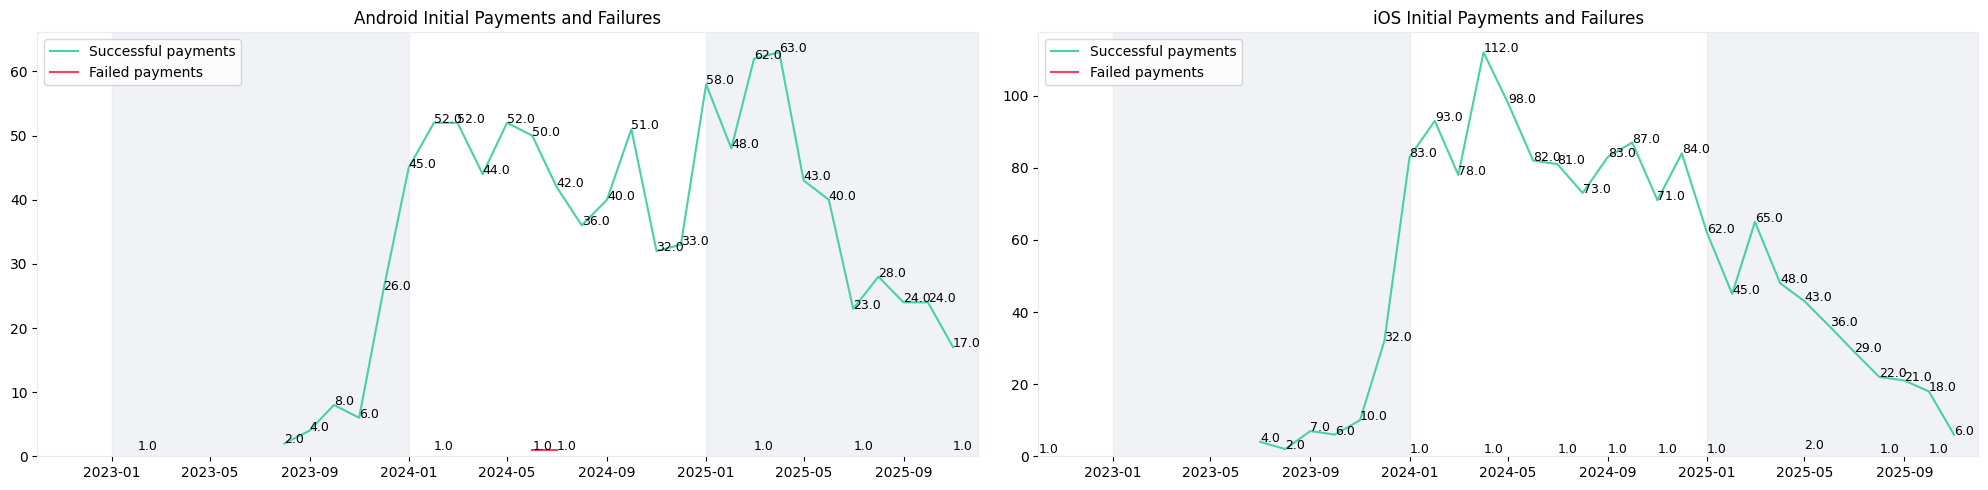

In [ ]:
payments_prep = payments[(payments['payment_type'] == 'initial')]


payments_data = payments_prep.merge(users, on = 'user_id', how = 'left')

payments_data['device_pay_status'] = (payments_data['device_type']
                                      + '_'
                                      + payments_data['payment_status'])

payments_data = payments_data[(payments_data['payment_start_date'] >= period_min) & (payments_data['payment_start_date'] <= period_max)]

payments_data = (payments_data.groupby(['registration_month', 'device_pay_status'], as_index = False)['payment_id'].nunique()
                                        .pivot(index = 'registration_month', columns = 'device_pay_status', values = 'payment_id')
                                        .reset_index())

fig, ax = plt.subplots(1, 2, figsize = (20, 5))

line_chart_formatting (payments_data,
                        'registration_month',
                        'android_succeeded',
                        chart_type = 'line',
                        title = 'Android Initial Payments and Failures',
                        main_color = '#47D1A5',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label =  'Successful payments',
                        min_y = 0,
                        ax = ax[0]
                        )

line_chart_formatting (payments_data,
                        'registration_month',
                        'android_failed',
                        chart_type = 'line',
                        title = 'Android Initial Payments and Failures',
                        main_color = '#F5405E',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Failed payments',
                        min_y = 0,
                        ax = ax[0]
                        )
ax[0].legend(loc = 'upper left')

line_chart_formatting (payments_data,
                        'registration_month',
                        'ios_succeeded',
                        chart_type = 'line',
                        title = 'iOS Initial Payments and Failures',
                        main_color = '#47D1A5',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Successful payments',
                        min_y = 0,
                        ax = ax[1]
                        )

line_chart_formatting (payments_data,
                        'registration_month',
                        'ios_failed',
                        chart_type = 'line',
                        title = 'iOS Initial Payments and Failures',
                        main_color = '#F5405E',
                        span = True,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Failed payments',
                        min_y = 0,
                        ax = ax[1]
                        )
ax[1].legend(loc = 'upper left')

plt.tight_layout()
plt.show()


#### **Intermediate Result**
Number of initial failed payments very small and does not explain the iOS conversion decline

## **2.7. Product mix**

Revenue also plateaus during the same period, so I check whether the subscription product mix changed - a shift toward lower-priced plans could weaken revenue.


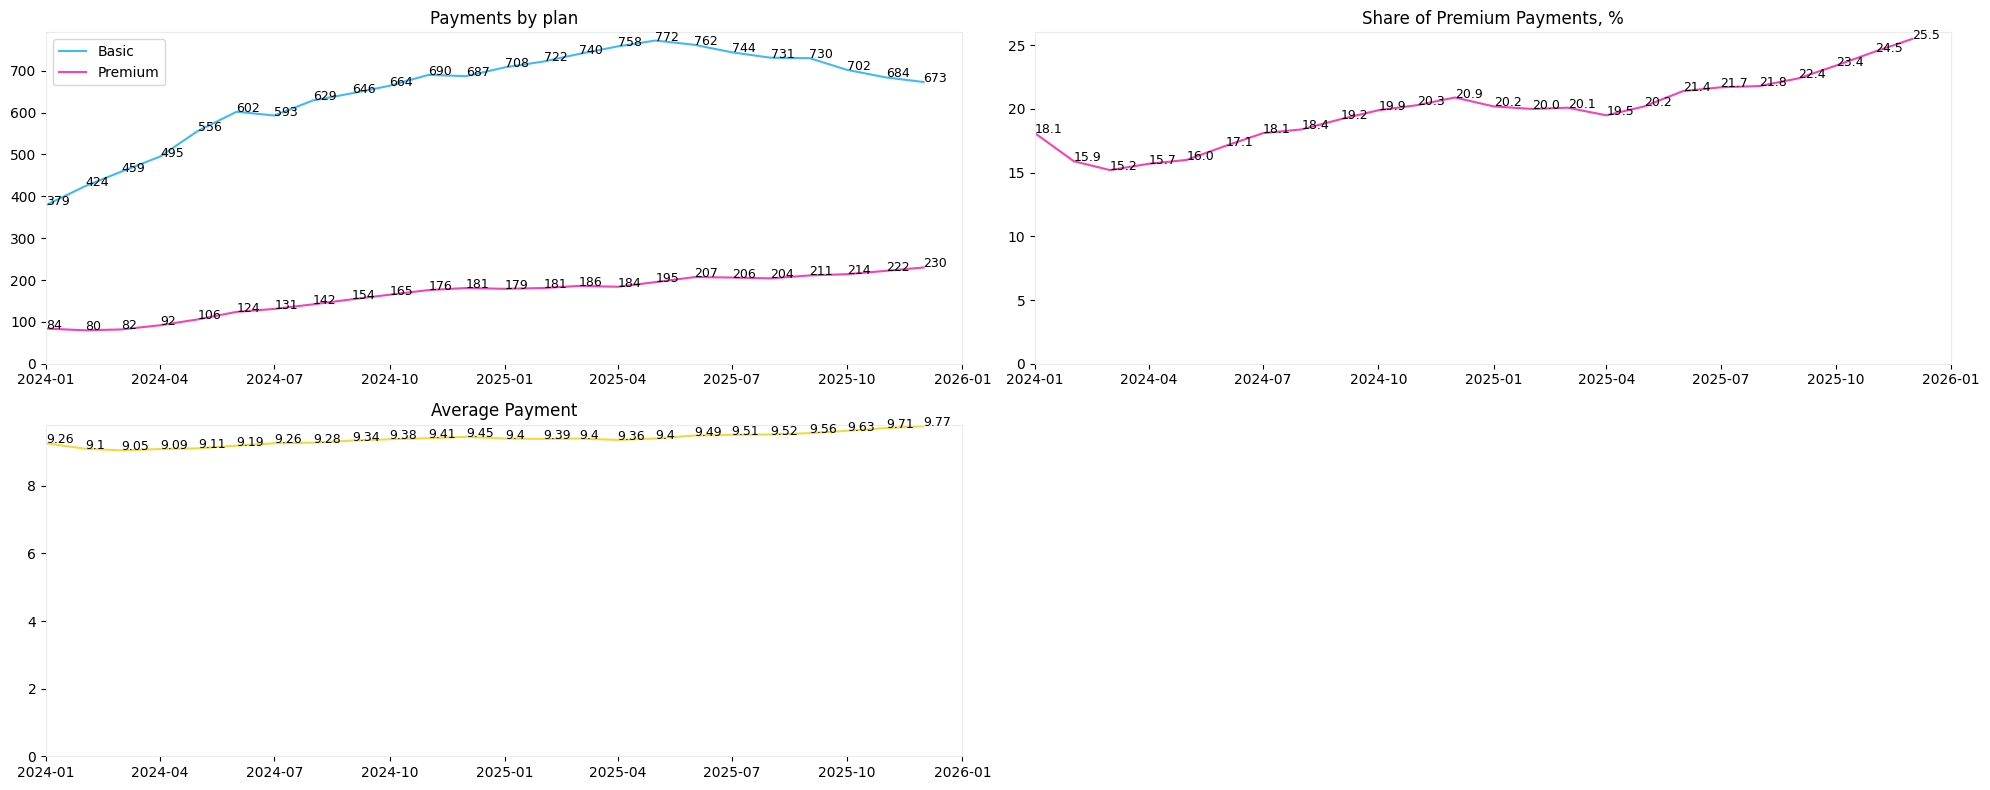

In [ ]:
payments['product'] = np.select([payments['amount_paid'] == 7.99, payments['amount_paid'] == 14.99],
                                ['Basic', 'Premium'],
                                'other')

payment_by_products = ((payments[(payments['payment_status'] == 'succeeded') & (payments['payment_month'] >= '2024-01-01')]
                       .groupby(['payment_month', 'product'], as_index = False).agg(payments = ('payment_id', 'nunique'), amount = ('amount_paid', 'sum')))
                      .pivot(index = 'payment_month', columns = 'product', values = ['payments', 'amount']).reset_index())


payment_columns = ['payment_month', 'Basic_payments', 'Premium_payments', 'Basic_amt', 'Premium_amt']
payment_by_products.columns = payment_columns

payment_by_products['Premium_payments'] = payment_by_products['Premium_payments'].astype(int)
payment_by_products['Basic_payments'] = payment_by_products['Basic_payments'].astype(int)

payment_by_products['prem_payments_share'] = round(payment_by_products['Premium_payments'] / (payment_by_products['Premium_payments'] + payment_by_products['Basic_payments']) * 100, 1)

payment_by_products['av_successful_payment'] = round((payment_by_products['Premium_amt'] + payment_by_products['Basic_amt'])
                                          / (payment_by_products['Premium_payments'] + payment_by_products['Basic_payments']), 2)

fig, ax = plt.subplots(2,2, figsize = (20, 8))


line_chart_formatting (payment_by_products,
                        'payment_month',
                        'Basic_payments',
                        chart_type = 'line',
                        title = 'Payments by plan',
                        main_color = '#42B9F5',
                        span = False,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Basic',
                        min_y = 0,
                        ax = ax[0,0]
                        )

line_chart_formatting (payment_by_products,
                        'payment_month',
                        'Premium_payments',
                        chart_type = 'line',
                        title = 'Payments by plan',
                        main_color = '#F542B9',
                        span = False,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = 'Premium',
                        min_y = 0,
                        ax = ax[0,0]
                        )
ax[0,0].legend(loc = 'upper left')

line_chart_formatting (payment_by_products,
                        'payment_month',
                        'prem_payments_share',
                        chart_type = 'line',
                        title = 'Share of Premium Payments, %',
                        main_color = '#F542B9',
                        span = False,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = None,
                        min_y = 0,
                        ax = ax[0,1]
                        )

line_chart_formatting (payment_by_products,
                        'payment_month',
                        'av_successful_payment',
                        chart_type = 'line',
                        title = 'Average Payment',
                        main_color = '#F5D742',
                        span = False,
                        span_period = 'Year',
                        span_color = '#EAEBF0',
                        data_labels = True,
                        label = None,
                        min_y = 0,
                        ax = ax[1,0]
                        )
ax[1,1].remove()
plt.tight_layout()
plt.show()


#### **Intermediate Result**

The product mix shifts toward Premium plan: its share increases from 18.1% to 25.5%, while average payment rises from 9.26 to 9.77

Therefore, lower-priced payment mix does not explain the revenue slowdown.


###**Final Result**

* Registration → Paid CR fell from **35.63% to 15.20% (-20.43 pp)**. Registrations increased from **2,551 to 3,453 (+35%)**, while paid users fell from **909 to 525 (-42%)**.
* The decline is concentrated on **iOS: 42.72% > 10.28% (-32.43 pp)**. Android declined only moderately from **25.00% > 22.58% (-2.42 pp)**.
* The iOS decline is distributed across channels, regions, and most age groups. No single audience segment explains it, so the issue is likely somewhere within the iOS Registration > Paid journey.
* Initial payment failures are too rare to influence for the decline
* The payment mix shifts toward Premium

### **Action plan**

* Check that iOS product event logs are recorded consistently.
* Compare product analytics data with backend data to identify any discrepancies.
* Check whether a new app version coincided with the conversion decline.
* Review whether any changes to the iOS Registration → Paid funnel were introduced during the same period.
* Research abandoned checkouts, and subscription activation issues.
* After the cause is addressed, monitor iOS CR to confirm recovery.

The portfolio dataset cannot confirm the root cause because it does not include event logs, release history, app-version data, or backend diagnostics.

### **Growth research**

* **Age 18–24 stands out across both platforms.**

  * Android CR increased from **2.56% to 21.55%**; users **234 to	283**; paid users **6 to 61**.
  * iOS CR declined from **13.33%	to 10.68%**, much less than other iOS age groups; users **255	to 487**; paid users **34	to 52**.
  * This may indicate stronger conversion potential among younger users.

* **Android Social and Influencer show positive signals.**

  * Social: CR **8.64% > 18.59%**; users **220 > 269**; paid users **19 > 50**.
  * Influencer: CR **5.34% > 23.08%**; users **131 > 169**; paid users **7 > 39**.
  * Both sources require further research but demonstrate potential

* **After the iOS issue is resolved, repeat the analysis to check whether the same age and channel patterns also appear on iOS**
